In [70]:
import keyword
import builtins
import tokenize
import io
import numpy as np


### Vocabulário Inicial

In [2]:
print(keyword.kwlist)
print(dir(builtins))

['False', 'None', 'True', 'and', 'as', 'assert', 'async', 'await', 'break', 'class', 'continue', 'def', 'del', 'elif', 'else', 'except', 'finally', 'for', 'from', 'global', 'if', 'import', 'in', 'is', 'lambda', 'nonlocal', 'not', 'or', 'pass', 'raise', 'return', 'try', 'while', 'with', 'yield']
['ArithmeticError', 'AssertionError', 'AttributeError', 'BaseException', 'BaseExceptionGroup', 'BlockingIOError', 'BrokenPipeError', 'BufferError', 'BytesWarning', 'ChildProcessError', 'ConnectionAbortedError', 'ConnectionError', 'ConnectionRefusedError', 'ConnectionResetError', 'DeprecationWarning', 'EOFError', 'Ellipsis', 'EncodingWarning', 'EnvironmentError', 'Exception', 'ExceptionGroup', 'False', 'FileExistsError', 'FileNotFoundError', 'FloatingPointError', 'FutureWarning', 'GeneratorExit', 'IOError', 'ImportError', 'ImportWarning', 'IndentationError', 'IndexError', 'InterruptedError', 'IsADirectoryError', 'KeyError', 'KeyboardInterrupt', 'LookupError', 'MemoryError', 'ModuleNotFoundError',

In [3]:
vocabulario_python = set(keyword.kwlist) | set(dir(builtins))
print(len(vocabulario_python))


192


In [40]:
list(vocabulario_python)[:5]

['with', 'dict', 'iter', 'repr', 'vars']

## Tokenizar arquivo e obter frequências de palavras

Recebendo o arquivo py, essa função é capaz de tokenizar ele, isso é uma etapa importante para que as palavras sejam recebidas. Além disso, também retorna a frequência das palavras.

In [76]:
def tokenizar_codigo(caminho_arquivo):
    with open(caminho_arquivo, 'r') as f:
        codigo = f.read()

    tokens = []
    frequencia = {}

    for tok in tokenize.generate_tokens(io.StringIO(codigo).readline):
        if tok.type not in (tokenize.NEWLINE, tokenize.NL,
                            tokenize.COMMENT, tokenize.ENCODING,
                            tokenize.ENDMARKER):
            if tok.string.strip():
                tokens.append(tok.string)
                frequencia[tok.string] = frequencia.get(tok.string, 0) + 1

    return tokens, frequencia

In [77]:
### Arquivo de teste para tokenização
conteudo = """def soma(a, b):
    x = a + b
    return x

somatorio = 0
somatorio = soma + 1
somatorio = soma(somatorio,2)
"""

with open("teste.py", "w") as f:
    f.write(conteudo)

In [88]:
tokens_teste,frequencia_teste = tokenizar_codigo("/content/teste.py")

### Obter nomes de variáveis e suas frequências

Essa é uma etapa importante, pois fora das palavras reservadas, também têm as definidas pelo próprio usuário, o nome das variáveis.

Isso pode ser feito analisando os tokens e extraindo os nomes ao verificar se vêm antes de símbolos, verificando, durante o processo, se já existem no conjunto, para evitar repetições

Mesmo que "=" seja o símbolo mais comum para essa verificação, há também operações por bits e comparativos, nesse caso, o correto é verificar também ">", "!" e "<", pois geralmente aparecem depois de uma variável

> if x != 0

> if x >= 0

> if y < 1

Além disso, é importante também verificar os parâmetros dentro da instância de uma função, pois não são definidos originalmente e sim passados à ela.

> def x (a, b): No caso de a e b (além de "x" que é um nome de função)



In [114]:
def retornar_variaveis(tokens, frequencia):
    variaveis = {}

    dentro_params = False

    for i, tok in enumerate(tokens):
        if tok == "=" and i > 0:
            if tokens[i-1] not in ("=", "!", "<", ">"):
                variaveis[tokens[i-1]] = frequencia.get(tokens[i-1], 0)

        if tok == "def" and i + 1 < len(tokens):
            variaveis[tokens[i+1]] = frequencia.get(tokens[i+1], 0)

        if tok == "(":
            dentro_params = True
        if tok == ")":
            dentro_params = False
        if dentro_params and tok not in ("(", ",", ")") and not tok.isnumeric():
            variaveis[tok] = frequencia.get(tok, 0)

    return variaveis

In [115]:
variaveis_teste = retornar_variaveis(tokens_teste,frequencia_teste)

In [116]:
variaveis_teste

{'soma': 3, 'a': 2, 'b': 2, 'x': 2, 'somatorio': 4}

Com isso é possível juntar o vocabulário todo em um só (com variáveis), além de também juntar o vocabulário de frequências

In [117]:
vocabulario_completo_teste = vocabulario_python | set(variaveis_teste.keys())
frequencia_completa_teste = frequencia_teste.copy()

for var, freq in variaveis_teste.items():
    frequencia_completa_teste[var] = frequencia_completa_teste.get(var, 0) + freq

In [118]:
list(vocabulario_completo_teste)[:5]

['with', 'dict', 'iter', 'repr', 'vars']

In [119]:
list(frequencia_completa_teste)[:5]

['def', 'soma', '(', 'a', ',']

## Obter candidatos

Um corretor automático funciona basicamente fazendo uma série de transformações em uma palavra, para formar um conjunto de palavras possíveis que podem ser feitas à partir dela numa certa distância (chamada n-distance). Essa distância leva em conta os caracteres modificados em sequência em uma palavra. 4 transformações são utilizadas nesse caso e são elas:


* Inserir: insere uma letra
* Delete: deleta uma letra
* Swift: troca uma letra de lugar
* Replace: troca uma letra

No entanto, essas mudanças não levam em conta diversos fatores. Uma palavra pode ter vários candidatos, porém o mais provável é aquele que:
> Requer menos transformações para se tornar aquela palavra
> Possui uma frequência maior (palavras menos "raras")

Com isso, esses dois pontos são levados em conta, calculando e armazenando a distância entre as palavras e também usando suas frequências para considerar o melhor candidato. Com isso feito, basta conferir qual dessas novas palavras estão de fato no dicionário, e somente as válidas são consideradas para os candidatos finais.

Geralmente essas mudanças incluem apenas caracteres no alfabeto, mas como estamos tratando também de nomes de variáveis, que podem incluir números, esses são considerados.
Isso já aumenta muito as possibilidades de palavras para um número pequeno "n", portanto, serão considerados usualmente somente até n=2.

In [120]:
#calcula a distância entre uma palavra e outra com base nas 4 transformações
def pegar_distancia(s1, s2):
    m, n = len(s1), len(s2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(
                    dp[i-1][j],
                    dp[i][j-1],
                    dp[i-1][j-1]
                )
            if i > 1 and j > 1 and s1[i-1] == s2[j-2] and s1[i-2] == s2[j-1]:
                dp[i][j] = min(dp[i][j], dp[i-2][j-2] + 1)

    return dp[m][n]

#gera os candidatos viáveis para cada palavra
def gerar_candidatos(palavra, n=1):
    alphabet = 'abcdefghijklmnopqrstuvwxyz_0123456789'

    def edit1(w):
        splits     = [(w[:i], w[i:]) for i in range(len(w) + 1)]
        deletes    = {L + R[1:]                for L, R in splits if R}
        inserts    = {L + c + R                for L, R in splits for c in alphabet}
        replaces   = {L + c + R[1:]            for L, R in splits if R for c in alphabet}
        transposes = {L + R[1] + R[0] + R[2:]  for L, R in splits if len(R) > 1}
        return deletes | inserts | replaces | transposes

    candidatos = {palavra: 0}
    for dist in range(1, n + 1):
        novos = {e for w in candidatos for e in edit1(w)}
        for c in novos:
            if c not in candidatos:
                candidatos[c] = dist

    return candidatos

Observe que até uma palavra pequena como int possui quase 30.000 candidatos.

In [121]:
candidatos_teste = gerar_candidatos("int",2)
print("Número de candidatos: ",len(candidatos_teste))
print(list(candidatos_teste)[:5])

Número de candidatos:  29378
['int', 'i2nt', '0nt', '8nt', '3nt']


Agora é só questão de pegar a palavra com a menor distância (ou seja, que requer menos transformações para se tornar a palavra que desejamos). Caso hajam empates considerando a distância, a palavra mais frequente é escolhida.

In [122]:
def verificar_palavra_existente(palavra, conjunto_palavras_candidatos, conjunto_palavras_real, frequencia):
    if palavra in conjunto_palavras_real:
        return palavra  # já existe

    candidatos_validos = {c: d for c, d in conjunto_palavras_candidatos.items() if c in conjunto_palavras_real}

    if candidatos_validos:
        # menor distância, desempatando pela maior frequência
        return min(candidatos_validos, key=lambda c: (candidatos_validos[c], -frequencia.get(c, 0)))
    else:
        return None  # nenhum candidato encontrado


In [123]:
verificar_palavra_existente("immt", candidatos_teste, vocabulario_python,frequencia_completa_teste)

'int'

Somente para fins de visualização, podemos plotar uma matriz de custo para transformação.
Para interpretar ela pense que é cumulativa e que portanto depende das letras passadas.

> para mudar de "" -> "i" o custo é 1

> para mudar de "" -> "int" o custo é 3

> para mudar de "i" -> "int" o custo é 2


In [124]:
def visualizar_matriz(s1, s2):
    m, n = len(s1), len(s2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])
            if i > 1 and j > 1 and s1[i-1] == s2[j-2] and s1[i-2] == s2[j-1]:
                dp[i][j] = min(dp[i][j], dp[i-2][j-2] + 1)

    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(dp, cmap='YlOrRd')

    ax.set_xticks(range(n + 1))
    ax.set_yticks(range(m + 1))
    ax.set_xticklabels([''] + list(s2), fontsize=14)
    ax.set_yticklabels([''] + list(s1), fontsize=14)

    for i in range(m + 1):
        for j in range(n + 1):
            ax.text(j, i, dp[i][j], ha='center', va='center', fontsize=12)

    plt.colorbar(im)
    plt.title(f'"{s1}" para "{s2}" | distância: {dp[m][n]}')
    plt.tight_layout()
    plt.show()

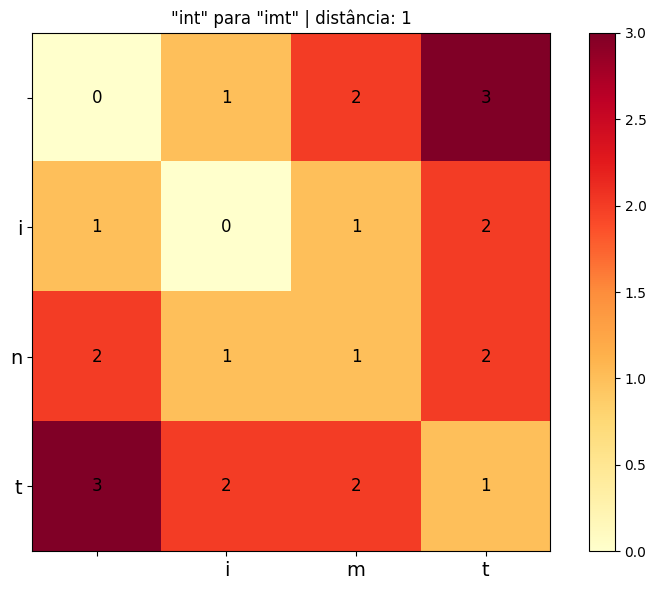

In [125]:
visualizar_matriz("int","imt")

## Juntando Tudo

Agora podemos fazer o pipeline completo, recebendo o arquivo .py com o código, irá tokenizá-lo e percorrer token por token para verificar discrepâncias, possivelmente as corrijindo. No final, irá retornar um código com as mudanças feitas.

Um adendo que uma função extra foi utilizada (**deve_corrigir**) para verificar se o token é um caractere único ou númerico, pois caso seja pode passar despercebido considerando as funções atuais e ser trocado por variáveis aleatórias.

> Ex: 2 virando uma variavel chamada "a"

In [158]:
def deve_corrigir(token):
    if len(token) == 1:
        return False
    if token.isnumeric():
        return False
    if token.startswith('"') or token.startswith("'"):
        return False
    return True

def corrigir_codigo(caminho_arquivo):
  codigo_tokenizado,frequencias = tokenizar_codigo(caminho_arquivo)
  variaveis = retornar_variaveis(codigo_tokenizado, frequencias)
  vocabulario_completo = vocabulario_python | set(variaveis.keys())
  frequencia_completa = frequencias.copy()
  tokens_corrigidos = []
  lista_alterado = []

  for var, freq in variaveis.items():
    frequencia_completa[var] = frequencia_completa.get(var, 0) + freq

  for token in codigo_tokenizado:
    if not deve_corrigir(token):
        tokens_corrigidos.append(token)
        lista_alterado.append(0)
        continue
    candidatos = gerar_candidatos(token,2)
    palavra_nova = verificar_palavra_existente(token, candidatos, vocabulario_completo,frequencia_completa)
    if palavra_nova == token:
      lista_alterado.append(0)
    else:
      lista_alterado.append(1)
    tokens_corrigidos.append(palavra_nova)

  return tokens_corrigidos,codigo_tokenizado,lista_alterado


def mostrar_resultados(tokens_corrigidos,codigo_tokenizado,lista_alterado):
    print("\n" + "="*40)
    print("       RESULTADO DO CORRETOR AUTOMÁTICO")
    print("="*40)
    print(f"verde  = mantido   vermelho = corrigido")
    print("-"*40)

    alteracoes = sum(lista_alterado)
    print(f"Total de tokens: {len(tokens_corrigidos)} | Correções: {alteracoes}")
    print("-"*40 + "\n")

    for token, alterado in zip(tokens_corrigidos, lista_alterado):
        if alterado:
            print(f"\033[91m{token}\033[0m", end=" ")
        else:
            print(f"\033[92m{token}\033[0m", end=" ")

    print("\n\n" + "-"*40)
    print("Original  ->  Corrigido")
    print("-"*40)
    for orig, corr, alt in zip(codigo_tokenizado, tokens_corrigidos, lista_alterado):
        if alt:
            print(f"  \033[91m{orig}\033[0m  →  \033[92m{corr}\033[0m")
    print("="*40 + "\n")

## Testes

Aqui alguns testes de unidade são feitos para verificar a funcionalidade do auto corretor.

In [160]:
### Arquivo de teste de falha em int
conteudo = """
x = imt(2.5)
"""

with open("teste_falha.py", "w") as f:
    f.write(conteudo)

In [161]:
tokens_corrigidos, codigo_tokenizado, lista_alterado = corrigir_codigo("teste_falha.py")
mostrar_resultados(tokens_corrigidos, codigo_tokenizado, lista_alterado)


       RESULTADO DO CORRETOR AUTOMÁTICO
verde  = mantido   vermelho = corrigido
----------------------------------------
Total de tokens: 6 | Correções: 1
----------------------------------------

x = int ( 2.5 ) 

----------------------------------------
Original  ->  Corrigido
----------------------------------------
  imt  →  int



In [162]:
### Arquivo de teste de falha em variavel
conteudo = """
var_a = 3
var_b = var_a + 3
var_c = var_aa + 2
print(var_c)
"""

with open("teste_falha2.py", "w") as f:
    f.write(conteudo)

In [163]:
tokens_corrigidos, codigo_tokenizado, lista_alterado = corrigir_codigo("teste_falha2.py")
mostrar_resultados(tokens_corrigidos, codigo_tokenizado, lista_alterado)


       RESULTADO DO CORRETOR AUTOMÁTICO
verde  = mantido   vermelho = corrigido
----------------------------------------
Total de tokens: 17 | Correções: 1
----------------------------------------

var_a = 3 var_b = var_a + 3 var_c = var_a + 2 print ( var_c ) 

----------------------------------------
Original  ->  Corrigido
----------------------------------------
  var_aa  →  var_a



In [164]:
### Arquivo de teste de falha em função
conteudo = """
def soma(a,b):
  return a + b

x = somar(1,3)
"""

with open("teste_falha3.py", "w") as f:
    f.write(conteudo)

In [165]:
tokens_corrigidos, codigo_tokenizado, lista_alterado = corrigir_codigo("teste_falha3.py")
mostrar_resultados(tokens_corrigidos, codigo_tokenizado, lista_alterado)


       RESULTADO DO CORRETOR AUTOMÁTICO
verde  = mantido   vermelho = corrigido
----------------------------------------
Total de tokens: 20 | Correções: 1
----------------------------------------

def soma ( a , b ) : return a + b x = soma ( 1 , 3 ) 

----------------------------------------
Original  ->  Corrigido
----------------------------------------
  somar  →  soma



In [166]:
### Arquivo de teste de falha em função
conteudo = """
def soma(a,b):
  return a + b

somatorio_x = somar(1,5)
somatorio_y = somatoria_x + 2
somatorio_z = somatoria_y + somatorio_x
"""

with open("teste_falha4.py", "w") as f:
    f.write(conteudo)

In [167]:
tokens_corrigidos, codigo_tokenizado, lista_alterado = corrigir_codigo("teste_falha4.py")
mostrar_resultados(tokens_corrigidos, codigo_tokenizado, lista_alterado)


       RESULTADO DO CORRETOR AUTOMÁTICO
verde  = mantido   vermelho = corrigido
----------------------------------------
Total de tokens: 30 | Correções: 3
----------------------------------------

def soma ( a , b ) : return a + b somatorio_x = soma ( 1 , 5 ) somatorio_y = somatorio_x + 2 somatorio_z = somatorio_y + somatorio_x 

----------------------------------------
Original  ->  Corrigido
----------------------------------------
  somar  →  soma
  somatoria_x  →  somatorio_x
  somatoria_y  →  somatorio_y

